# Exploratory Data Analysis (EDA) On Titanic Dataset

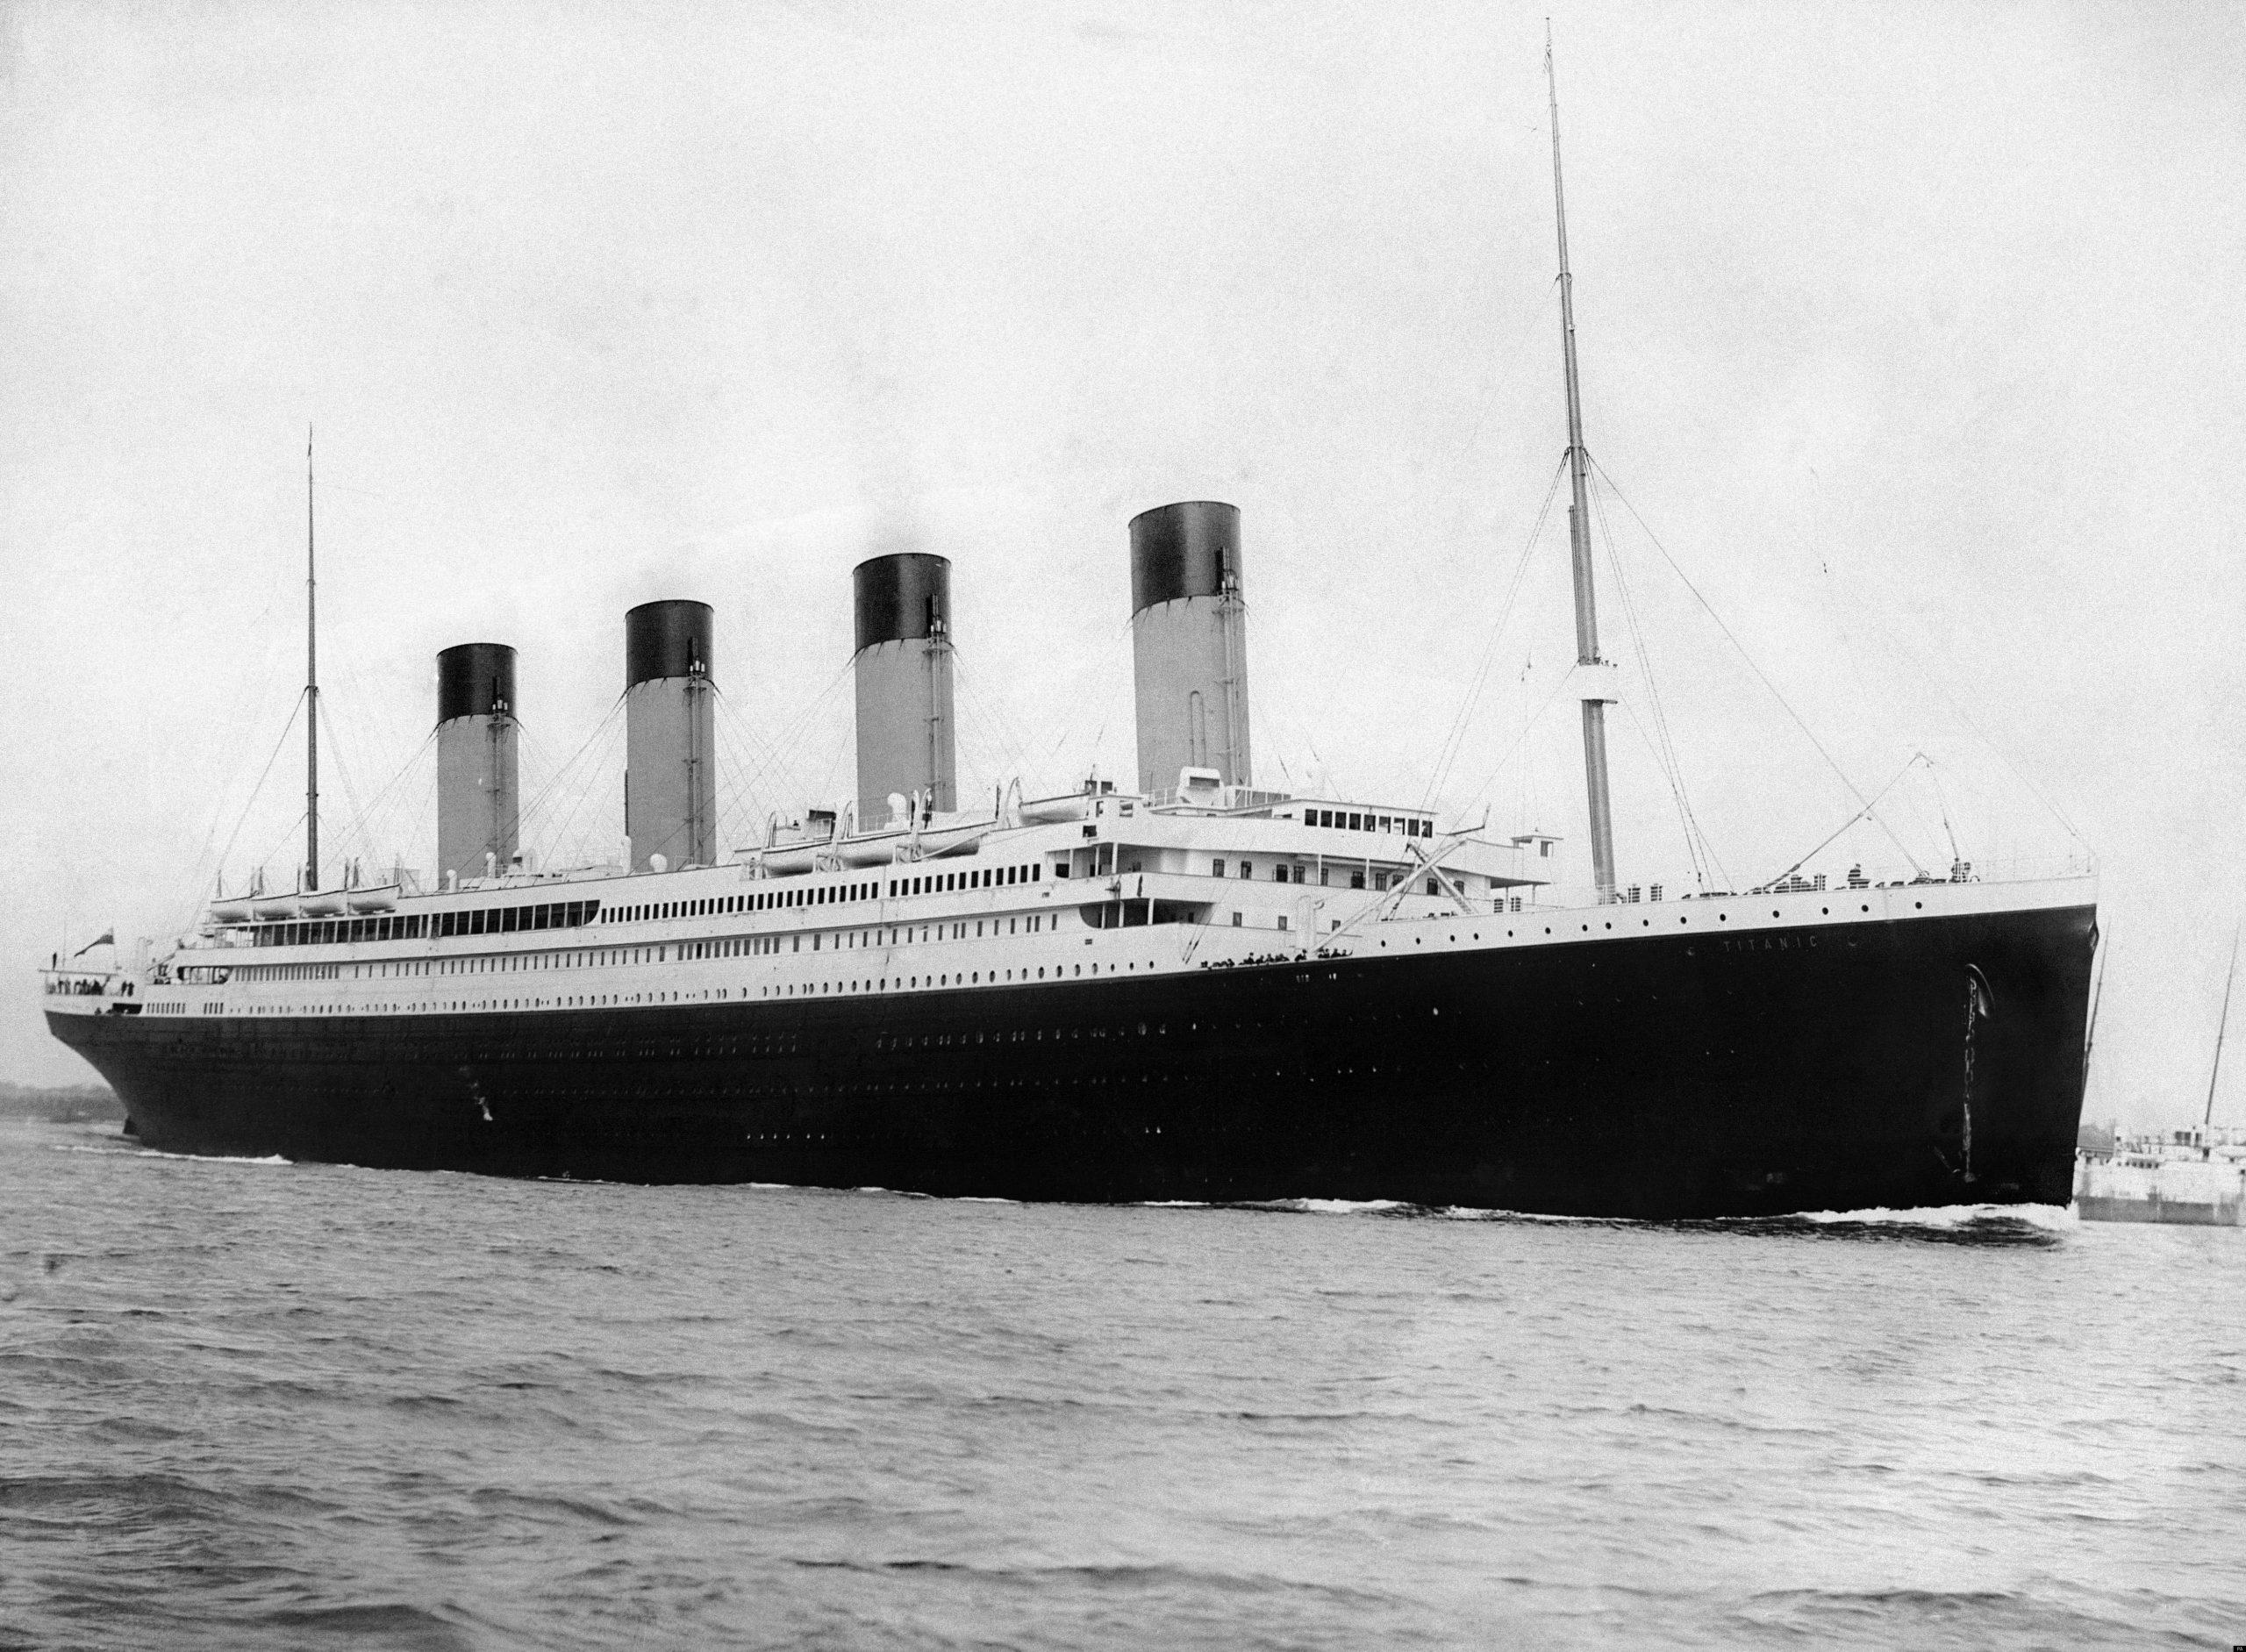

In [1]:
from IPython.display import Image, display

display(Image(filename='titanic.jpg', width=800, height=1200))

# 🚢 Titanic Dataset - Exploratory Data Analysis (EDA)

## Introduction

The sinking of the RMS Titanic on April 15, 1912, remains one of the most tragic maritime disasters in history. During its maiden voyage from Southampton to New York City, the ship struck an iceberg and sank, resulting in the loss of more than 1,500 lives. While the event was catastrophic, it also revealed that survival was influenced by several factors such as age, gender, passenger class, family size, and ticket fare.

The Titanic dataset is one of the most widely used datasets in the fields of Data Science and Machine Learning. It provides demographic and travel-related information about passengers, making it an excellent dataset for learning data preprocessing, visualization, feature analysis, and predictive modeling.

In this notebook, we perform a comprehensive Exploratory Data Analysis (EDA) to better understand the dataset and uncover the factors that influenced passenger survival. Through statistical summaries, data visualizations, and feature-wise exploration, we aim to identify meaningful patterns, detect missing values and outliers, and prepare the data for future machine learning models.

## Objectives

The primary objectives of this Exploratory Data Analysis are:

- Understand the structure and characteristics of the dataset.
- Examine the distribution of numerical and categorical features.
- Identify and handle missing values.
- Detect duplicate records and potential outliers.
- Explore relationships between passenger attributes and survival.
- Analyze the influence of passenger class, gender, age, fare, family size, and port of embarkation.
- Discover trends and patterns through visualizations.
- Generate actionable insights from the data.
- Prepare a clean dataset suitable for predictive modeling.
  
## About the Dataset

The Titanic dataset contains information about passengers aboard the RMS Titanic. Each row represents an individual passenger, while each column describes a specific attribute related to that passenger.

### Some of the important features include:

| Feature     | Description                                  |
|------------|----------------------------------------------|
| PassengerId | Unique identifier assigned to each passenger |
| Survived    | Survival status (0 = No, 1 = Yes)            |
| Pclass      | Passenger class (1st, 2nd, 3rd)              |
| Name        | Passenger's full name                        |
| Sex         | Gender of the passenger                      |
| Age         | Age in years                                 |
| SibSp       | Number of siblings/spouses aboard            |
| Parch       | Number of parents/children aboard            |
| Ticket      | Ticket number                                |

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 
import plotly.express as px
import plotly.graph_objects as go


In [3]:
# load the dataset
df = pd.read_csv('train.csv')

In [4]:
# info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# shape of the dataset 
df.shape

(891, 12)

In [6]:
# describe the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [7]:
# check the missing values in the dataset
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

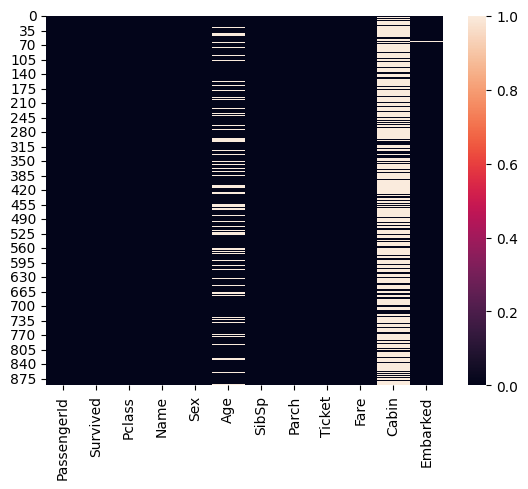

In [8]:
# visualize the missing values in the dataset
import seaborn as sns
sns.heatmap(df.isnull())

In [9]:
# finding the Unique values in the dataset
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

### Initial Observation
- The dataset is well-structured and contains 891 passenger records with 12 features.
- Missing values are present only in the Age, Cabin, and Embarked columns.
- The dataset includes a mix of numerical and categorical variables, making it suitable for both statistical analysis and visualization.
- Data preprocessing, including handling missing values and encoding categorical variables, will be required before model building.

In [10]:
# Check the number of duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [11]:
# classify the columns into categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()


In [12]:
print("🎨 Variable Classification:")
print("="*40)
print(f"Categorical Variables ({len(categorical_columns)}):", categorical_columns)
print(f"\nNumerical Variables ({len(numerical_columns)}):", numerical_columns)


🎨 Variable Classification:
Categorical Variables (5): ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

Numerical Variables (7): ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [13]:
df[['Age','Fare']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


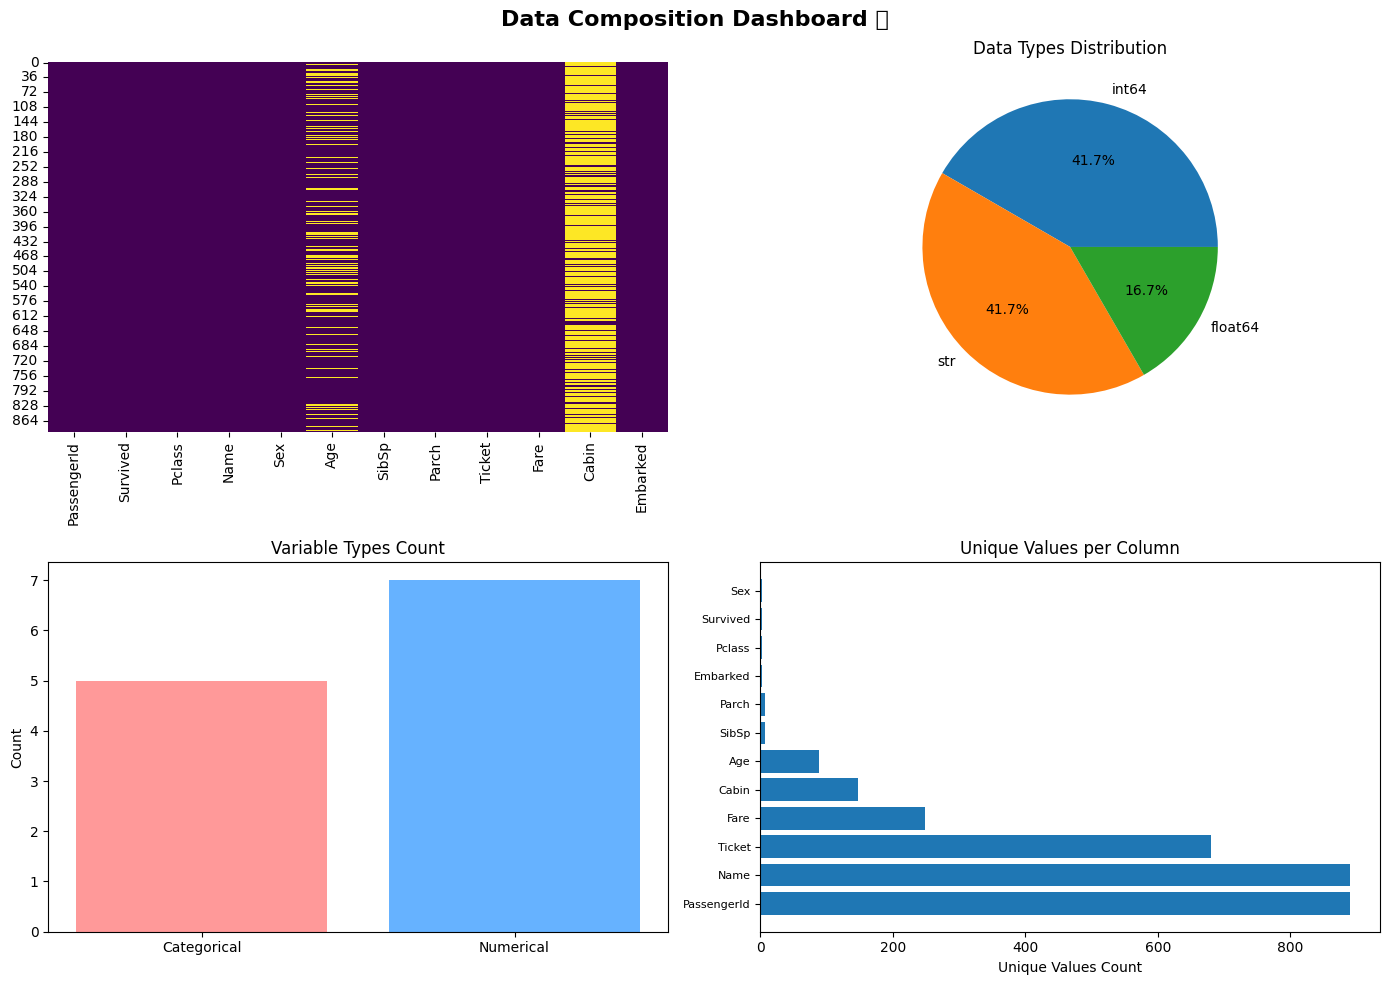

In [14]:
# Eagle Eye View of the Dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Data Composition Dashboard 📊', fontsize=16, fontweight='bold')

# Data types pie chart
dtype_counts = df.dtypes.value_counts()
axes[0,1].pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%')
axes[0,1].set_title('Data Types Distribution')

# heatmap of missing values
sns.heatmap(df.isnull(), ax=axes[0,0], cbar=False, cmap='viridis')


# Categorical vs Numerical
axes[1,0].bar(['Categorical', 'Numerical'], [len(categorical_columns), len(numerical_columns)], color=['#FF9999', '#66B2FF'])
axes[1,0].set_title('Variable Types Count')
axes[1,0].set_ylabel('Count')

# Unique values per column
unique_counts = df.nunique().sort_values(ascending=False)
axes[1,1].barh(range(len(unique_counts)), unique_counts.values)
axes[1,1].set_yticks(range(len(unique_counts)))
axes[1,1].set_yticklabels(unique_counts.index, fontsize=8)
axes[1,1].set_title('Unique Values per Column')
axes[1,1].set_xlabel('Unique Values Count')

plt.tight_layout()
plt.show()

### Interpretation

- There are no duplicate rows in this dataset. 
- Numerical columns in the Dataset are 'PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'.
- Categorical columns in the Datasets are 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'.
- Data composition dashboard shows the heatmap, which shows Cabin has the largest number of missing values, that needs to be handled.
  

# Missing Value Imputation

In [15]:
# find out the percentage of missing values
df.isnull().sum() / len(df) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [16]:
#1- drop the column having more than 70% of missing values from dataset
df.drop('Cabin', axis=1, inplace=True)

In [17]:
# checking mean of the Age column
df['Age'].mean()


np.float64(29.69911764705882)

In [18]:
df['Age'].median()

np.float64(28.0)

In [19]:
df['Age'].mode()[0]

np.float64(24.0)

In [20]:
# Fill missing values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

Observation

The missing values in the **Age** feature were successfully replaced using the median value. This approach retained all passenger records while minimizing the impact of outliers on the imputed values. The resulting age distribution remained consistent with the original data, making it suitable for further analysis.

In [21]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [22]:
# Fill missing values with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Observation: 

The missing values in the **Embarked** feature were successfully imputed using the mode (most frequent category). This method retained all passenger records and preserved the overall distribution of embarkation ports. After imputation, the dataset contained no missing values in the **Embarked** column.

In [23]:
df.isnull().sum() / len(df) * 100

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

<Axes: >

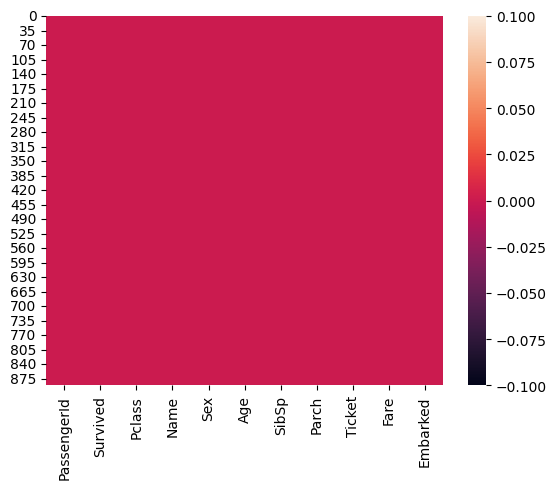

In [24]:
sns.heatmap(df.isnull())

# Univariate Analysis of the Dataset


## 1. Survived Distribution 

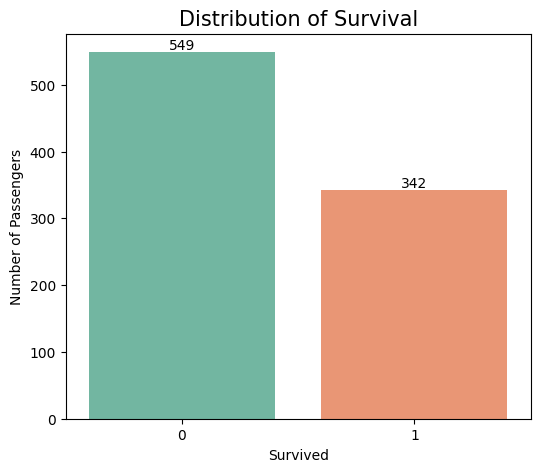

In [25]:
plt.figure(figsize=(6,5))

ax = sns.countplot(x='Survived', data=df, palette='Set2')

plt.title("Distribution of Survival", fontsize=15)
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Observation: The plot indicates that out of 891 passengers, only 342 survived and 549 could not survive.

## 2. Passenger Class Distribution 

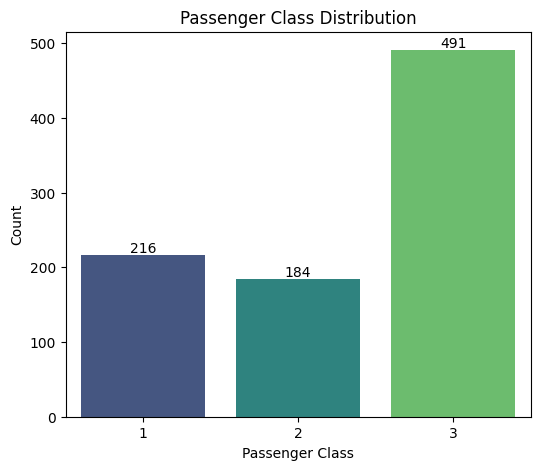

In [26]:
plt.figure(figsize=(6,5))

ax = sns.countplot(x='Pclass', data=df, palette='viridis')

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Observation: Most passengers belonged to the third passenger class, indicating that the majority of travelers were from the lower socioeconomic class.

## 3. Gender Distribution 


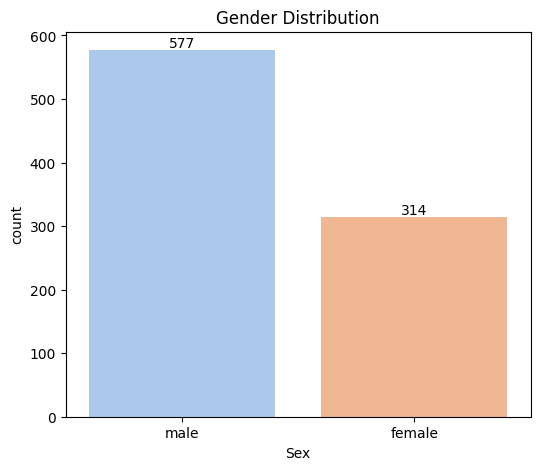

In [27]:
plt.figure(figsize=(6,5))

ax = sns.countplot(x='Sex', data=df, palette='pastel')

plt.title("Gender Distribution")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Observation: In the dataset Male count is 577 which is more than females i.e. 314.


## 4. Embarked Distribution 

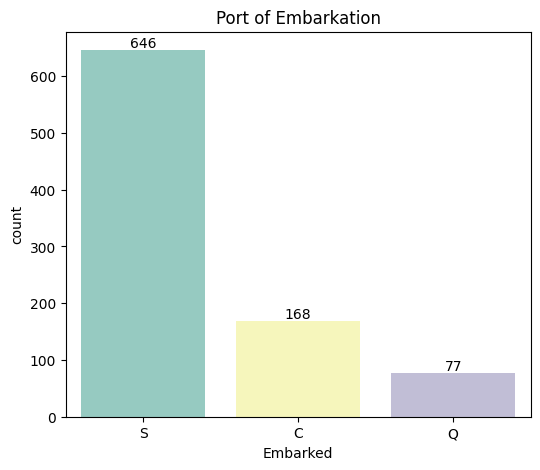

In [28]:
plt.figure(figsize=(6,5))

ax = sns.countplot(x='Embarked', data=df, palette='Set3')

plt.title("Port of Embarkation")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Observation: most of the passengers emabrked from Southampton, 168 embarked from  Cherbourg and only 77 embarked from Queenstown. 

## 5. Sibling Spouse Distribution 

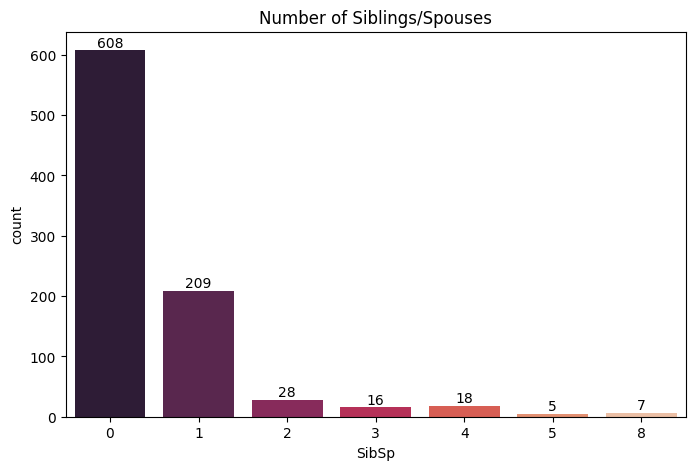

In [29]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='SibSp', data=df, palette='rocket')

plt.title("Number of Siblings/Spouses")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## 6. Parent/Children Distribution 

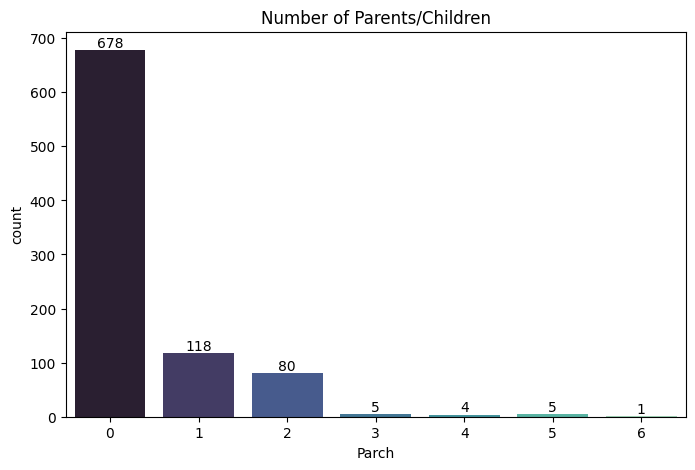

In [30]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='Parch', data=df, palette='mako')

plt.title("Number of Parents/Children")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## 7. Age Distribution

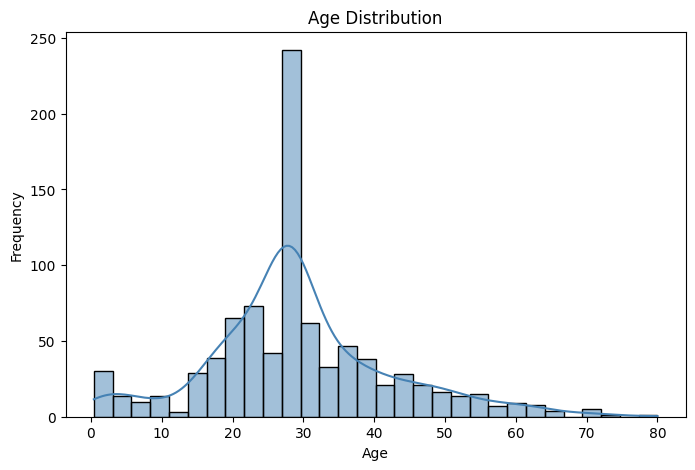

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True, color='steelblue')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Observation: The age distribution is right-skewed, with most passengers between 20 and 40 years old. A few elderly passengers create a long right tail.

## 8. Fare Distribution

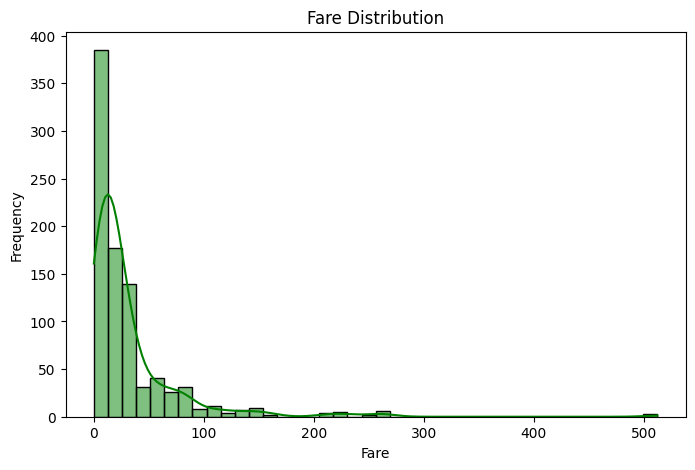

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df['Fare'], bins=40, kde=True, color='green')

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

Observation: The fare distribution is highly right-skewed, with several high-value outliers representing passengers who paid premium ticket prices.

# 🚨 Outlier Detection

Outliers are observations that differ significantly from the rest of the data. They may result from measurement errors, data entry mistakes, or represent genuine but rare observations.

In this section, we will:
- Visualize outliers using boxplots.
- Detect outliers using the Interquartile Range (IQR) method.
- Count the number of outliers in each numerical feature.
- Decide whether any treatment is required.

In [33]:
# Select Numerical features
numerical_columns = ['Age', 'Fare', 'SibSp', 'Parch']

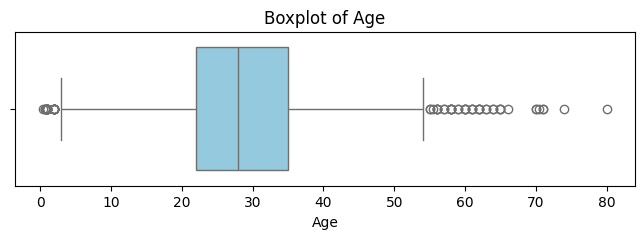

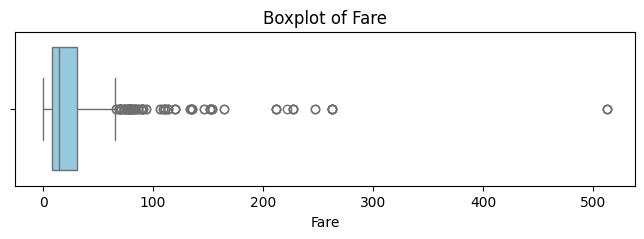

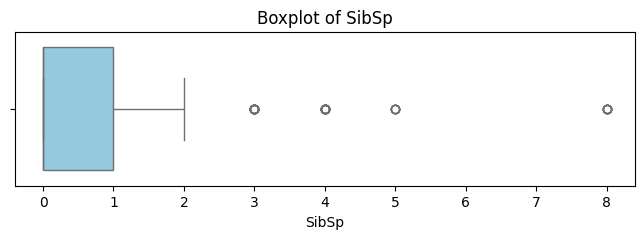

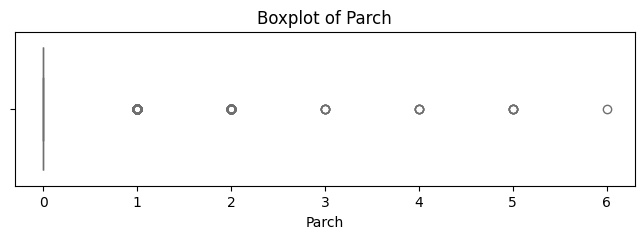

In [34]:
for feature in numerical_columns:
    
    plt.figure(figsize=(8,2))
    
    sns.boxplot(x=df[feature], color='skyblue')
    
    plt.title(f'Boxplot of {feature}')
    
    plt.show()

In [35]:
# Detect outliers using IQR method
def detect_outliers(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    
    return outliers

In [36]:
# count the number of outliers in each numerical feature

for feature in numerical_columns:
    
    outliers = detect_outliers(df, feature)
    
    print(f"{feature}: {len(outliers)} outliers")

Age: 66 outliers
Fare: 116 outliers
SibSp: 46 outliers
Parch: 213 outliers


In [37]:
# percentage of outliers in each numerical feature
for feature in numerical_columns:
    
    outliers = detect_outliers(df, feature)
    
    percentage = len(outliers)/len(df)*100    
    print(f"{feature}: {percentage:.2f}%")

Age: 7.41%
Fare: 13.02%
SibSp: 5.16%
Parch: 23.91%


In [38]:

# Display the summary of outliers in each numerical feature
summary = []

for feature in numerical_columns:
    
    outliers = detect_outliers(df, feature)
    
    summary.append({
        "Feature": feature,
        "Outliers": len(outliers),
        "Percentage": round(len(outliers)/len(df)*100,2)
    })

outlier_summary = pd.DataFrame(summary)

outlier_summary

,Feature,Outliers,Percentage
0,Age,66,7.41
1,Fare,116,13.02
2,SibSp,46,5.16
3,Parch,213,23.91


## 📝 Observations

- **Age** contains a small number of extreme values, representing very young infants and elderly passengers.
- **Fare** exhibits the largest number of outliers due to a few passengers paying exceptionally high ticket prices.
- **SibSp** and **Parch** have several high values, but these represent passengers traveling with unusually large families.
- Most detected outliers appear to be legitimate observations rather than data entry errors.

We will not remove outliers in this Dataset due to following reasons. 

- High fares are genuine (e.g., first-class luxury tickets).
- Elderly passengers and infants are valid observations.
- Large family sizes are rare but real.

# 🎯 Key Determinants of Passenger Survival

### Survival by Gender ⭐

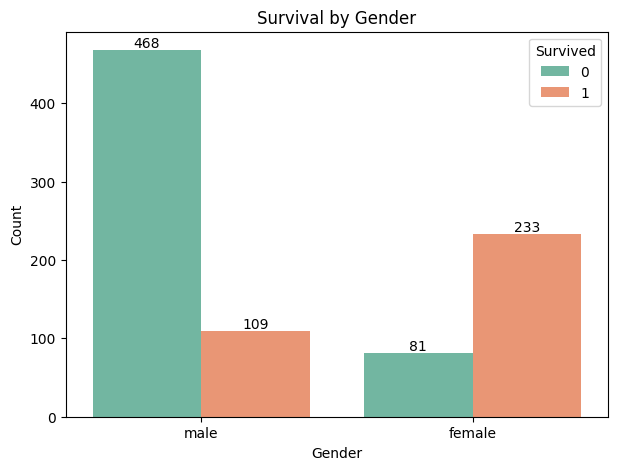

In [39]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x='Sex', hue='Survived', palette='Set2')

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Observation:

Female passengers had a significantly higher survival rate than male passengers, supporting the "women and children first" evacuation policy.

### Survival by Passenger Class ⭐

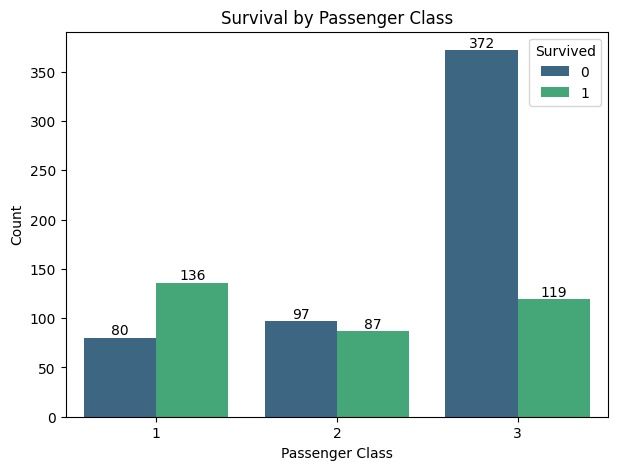

In [40]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x='Pclass', hue='Survived', palette='viridis')

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Observation: First-class passengers had the highest survival rate, while third-class passengers experienced the highest mortality.

### Age Distribution by Survival ⭐

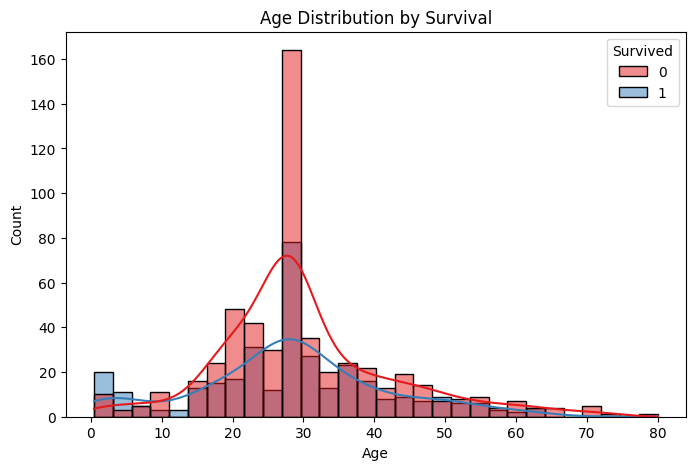

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Survived',
    kde=True,
    bins=30,
    palette='Set1'
)

plt.title("Age Distribution by Survival")

plt.show()

Observation: Younger passengers, particularly children, showed relatively higher survival rates compared with older passengers.

### Fare vs Survival ⭐

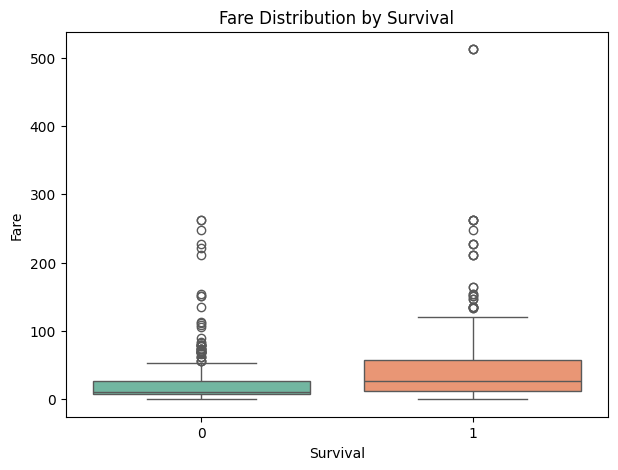

In [42]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Survived', y='Fare', palette='Set2')

plt.title("Fare Distribution by Survival")
plt.xlabel("Survival")
plt.ylabel("Fare")

plt.show()

Observation: Survivors generally paid higher ticket fares, suggesting a relationship between socioeconomic status and survival.

# Correlation Analysis


### 🔗 Correlation Analysis

Correlation analysis helps us understand the strength and direction of the relationship between numerical variables. It identifies whether an increase or decrease in one variable is associated with changes in another.

In this section, we use a correlation matrix and pairplots to explore relationships among the numerical features in the Titanic dataset.

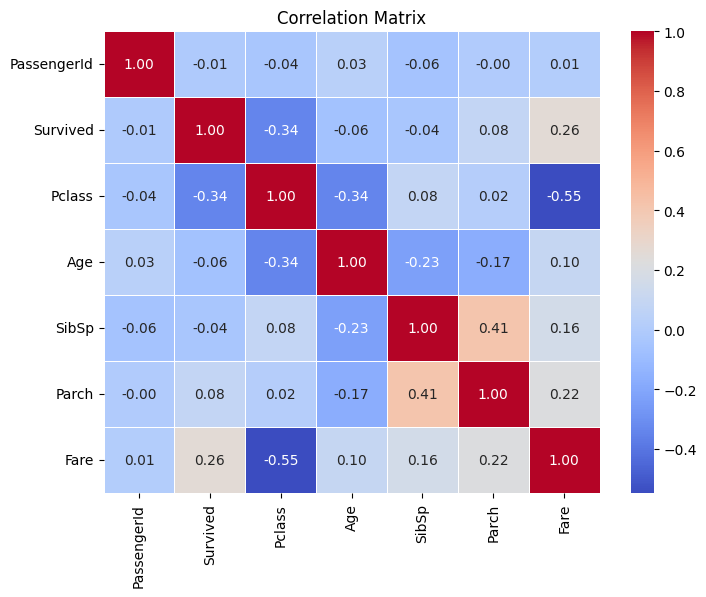

In [43]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Observation

- Most numerical features exhibit weak correlations with one another.
- **Fare** shows a moderate negative correlation with **Pclass**, indicating that passengers in higher classes generally paid higher fares.
- **Survived** has a positive correlation with **Fare** and a negative correlation with **Pclass**, suggesting that passengers who paid higher fares or traveled in higher classes were more likely to survive.
- **SibSp** and **Parch** have a slight positive correlation, indicating that passengers traveling with siblings or spouses often traveled with parents or children as well.
- No pair of numerical features exhibits very strong multicollinearity, suggesting that each feature contributes distinct information.

# Pairplot

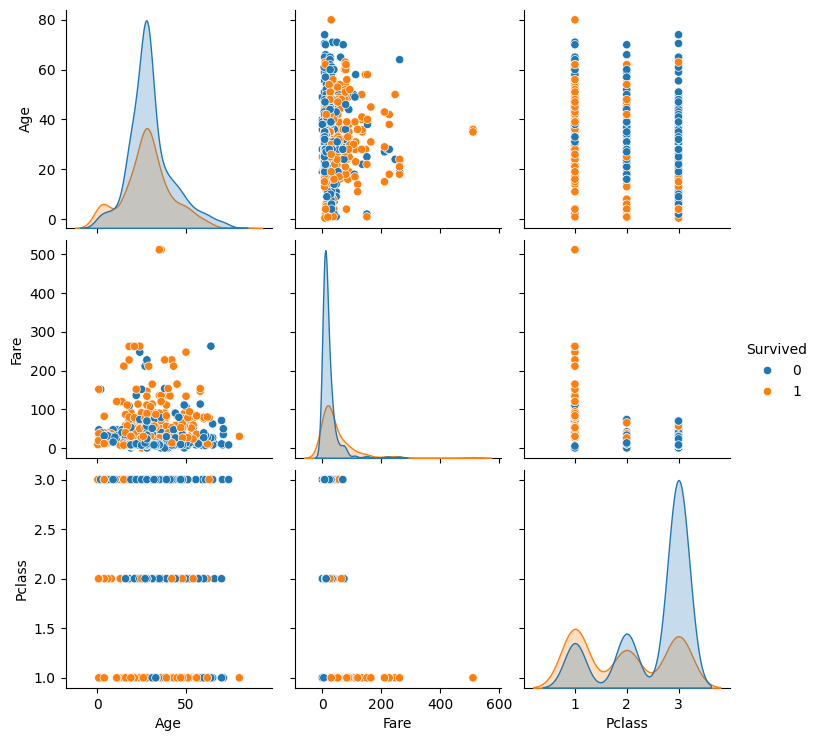

In [44]:
sns.pairplot(
    df[['Survived', 'Age', 'Fare', 'Pclass']],
    hue='Survived',
    diag_kind='kde'
)

plt.show()

### Observation

- Passengers who survived are more concentrated among those who paid higher fares and traveled in higher passenger classes.
- The relationship between **Age** and **Survived** is less distinct, although younger passengers appear to have slightly better survival outcomes.
- **Fare** is positively associated with survival, while **Pclass** shows an inverse relationship with survival.
- The distributions indicate that no single numerical feature alone can perfectly distinguish survivors from non-survivors, suggesting that survival depended on a combination of factors.

# 📌 Feature Engineering: Age Group Binning

In [45]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [46]:
df.Age.min()

np.float64(0.42)

In [47]:
df.Age.max()

np.float64(80.0)

<Axes: xlabel='Age', ylabel='Count'>

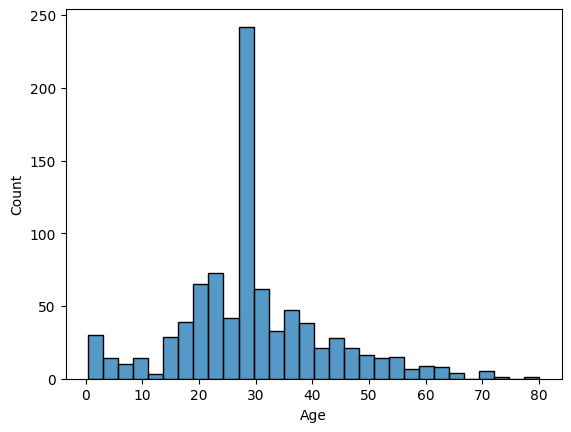

In [49]:
sns.histplot(df['Age'])

In [50]:
# Define bins and labels
bins = [0, 1, 5, 12, 18, 30, 50, 100]
labels = ['Infants', 'Toddlers', 'Kids', 'Teens', 'Young Adults', 'Adults', 'Seniors']

# Create a new Age_Group column
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

In [ ]:
# Display the value counts of the Age_Group column
df['Age_Group'].value_counts().sort_index()

Age_Group
Infants          14
Toddlers         30
Kids             25
Teens            70
Young Adults    447
Adults          241
Seniors          64
Name: count, dtype: int64

In [ ]:
# Display the first few rows of the DataFrame to verify the new Age_Group column
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Young Adults
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adults
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Young Adults
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Adults
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Adults


### Visualize the Age groups

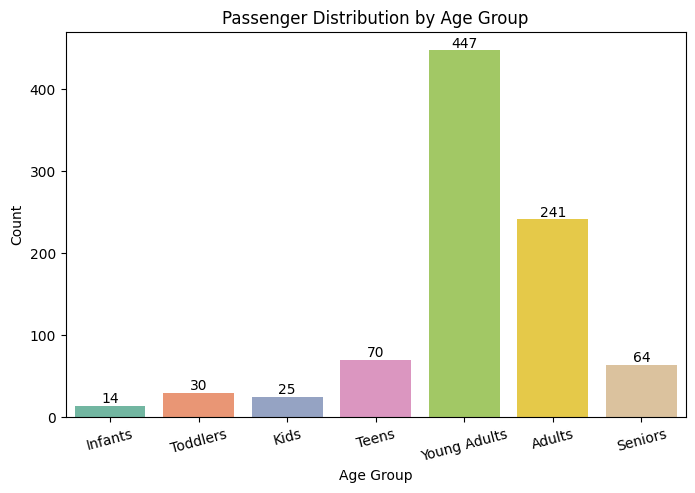

In [53]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='Age_Group', palette='Set2')

plt.title("Passenger Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=15)
plt.show()

### Observation

- The majority of passengers belonged to the **Young Adults (18–30 years)** and **Adults (30–50 years)** age groups.
- Very few passengers were categorized as **Infants** or **Toddlers**, indicating that young children made up only a small proportion of the passengers.
- The number of **Senior** passengers was relatively low compared to other age groups.
- Overall, the passenger population was predominantly composed of young and middle-aged adults.

### Analyze Survival by Age groups 

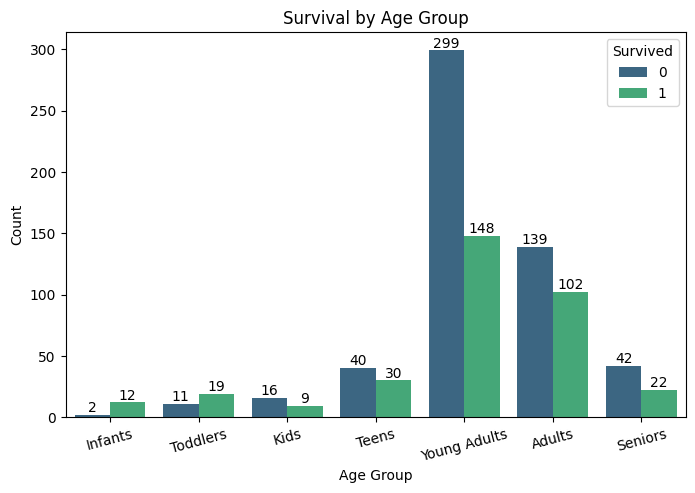

In [54]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Age_Group',
    hue='Survived',
    palette='viridis'
)

plt.title("Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=15)
plt.show()

### Observation

- The **Young Adults (18–30 years)** age group had the highest number of passengers and, consequently, recorded the highest number of both survivors and non-survivors.
- Although **Young Adults** formed the largest passenger group, the number of non-survivors (299) was considerably higher than the number of survivors (148), indicating a relatively low survival rate within this age category.
- **Adults (30–50 years)** represented the second-largest age group, with more non-survivors (139) than survivors (102).
- **Infants** and **Toddlers** had relatively few passengers, but survivors outnumbered non-survivors in both groups, suggesting that very young children had a higher chance of survival.
- **Teenagers**, **Kids**, and **Seniors** had fewer passengers overall, and in each of these groups, non-survivors slightly exceeded survivors.
- Overall, the chart suggests that younger children experienced better survival outcomes, whereas adult age groups had higher mortality. However, the large number of Young Adults and Adults on board also contributed to their higher counts of both survivors and non-survivors.

# Survival rate percentage on the basis of Age Groups

In [55]:
# Calculate survival rate by age group
survival_rate = pd.crosstab(
    df['Age_Group'],
    df['Survived'],
    normalize='index'
) * 100

survival_rate.round(2)

Survived,0,1
Age_Group,,
Infants,14.29,85.71
Toddlers,36.67,63.33
Kids,64.00,36.00
Teens,57.14,42.86
Young Adults,66.89,33.11
Adults,57.68,42.32
Seniors,65.62,34.38


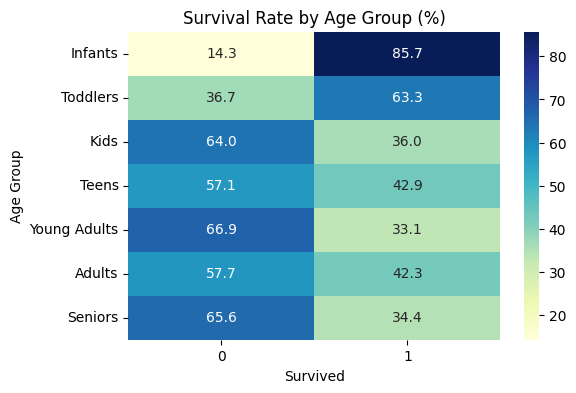

In [56]:
plt.figure(figsize=(6,4))

sns.heatmap(
    survival_rate,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Survival Rate by Age Group (%)")
plt.xlabel("Survived")
plt.ylabel("Age Group")

plt.show()

### Observation

- The survival rate was highest among **Infants** and **Toddlers**, indicating that very young children were given priority during the evacuation process.
- **Adults** exhibited a higher survival rate than **Young Adults**, even though Young Adults constituted the largest passenger group.
- **Young Adults** and **Seniors** showed comparatively lower survival percentages, suggesting these groups were less likely to survive.
- The percentage-based analysis provides a more meaningful comparison than raw passenger counts, as it accounts for the different number of passengers in each age group.
- Overall, the findings indicate that **age influenced survival**, with younger children generally having a better chance of survival than older passengers.

# 🧹 Data Filtration

In [57]:
# based on column
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Age_Group'],
      dtype='str')

In [58]:
df_01 = df[['Survived','Age_Group','Fare','Pclass']]

In [59]:
df_01.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Survived   891 non-null    int64   
 1   Age_Group  891 non-null    category
 2   Fare       891 non-null    float64 
 3   Pclass     891 non-null    int64   
dtypes: category(1), float64(1), int64(2)
memory usage: 22.2 KB


### Distribution of Passenger class

In [60]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Observations:

The majority of passengers traveled in Third Class (Pclass = 3) with 491 passengers (55.1%).
First Class had 216 passengers (24.2%).
Second Class had 184 passengers (20.7%).
This indicates that the Titanic carried significantly more lower-class passengers than upper-class passengers.

### Filtering First class Passengers 

In [62]:
# filter the data based on rows criteria
df_first = df_01[df_01['Pclass'] == 'First']

Observations:

The dataset was filtered to include only First-Class passengers.
This subset can be used to analyze survival rates, fares, or age groups specifically for First-Class travelers.
Filtering data into subsets makes it easier to perform targeted analysis.

### Filtering High Fare passengers

In [63]:
# lets select only those rows whihc have paid more than 200 Pounds
df_200 = df_01[df_01['Fare'] > 81]

In [65]:
df_200['Pclass'].value_counts()

Pclass
1    74
Name: count, dtype: int64

Observations:

After filtering passengers who paid more than 81 pounds, 74 passengers remained.
All of these passengers belonged to First Class (Pclass = 1).
No Second-Class or Third-Class passenger paid more than 81 pounds in this dataset.
This suggests a strong relationship between ticket fare and passenger class, where higher fares were almost exclusively associated with First-Class travel.

# 📋 Key Insights


- Female passengers had a substantially higher survival rate than males.
- First-class passengers were more likely to survive than second- and third-class passengers.
- Higher ticket fares were generally associated with better survival outcomes.
- Most passengers were between 18 and 50 years of age.
- Infants and toddlers exhibited the highest survival percentages.
- Fare showed a moderate relationship with passenger class and survival.
- Missing values in the Age, Cabin and  Embarked columns were successfully handled using appropriate imputation techniques.
- Data filtering reveals that the majority of Titanic passengers belonged to Third Class. Additionally, passengers paying more than 81 pounds were exclusively from First Class, indicating that ticket fare is strongly associated with passenger class. Creating filtered subsets allows focused analysis of specific passenger groups and supports more meaningful exploratory data analysis.